# PyTorch Workflow


1.  Get data ready(turn into tensors)
2.  Build or pick a pretrained model
     * Pick a loss function and optimizer
     *  Build a training loop
     *  repeat
3.  Fit the model to the data and make a prediction
4. Evaluate the model
5.  Improve through experimentation
6. Save and reload your trained model


here is the link to the material:https://www.learnpytorch.io/01_pytorch_workflow/




In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.9.0+cu126'

# `torch.nn`
`torch.nn` is PyTorch’s neural-network toolbox.
Not magic. Not “AI”. Just a collection of ready-made `building blocks` so you don’t have to reinvent linear algebra like it’s 1950.

1. `Layers (the stuff that learns)`
    * nn.Linear
    * nn.Conv2d
    *  nn.LSTM
    * nn.Embedding.
  * These contain weights and biases. They are trainable. That’s the whole
  point.
2.  `Activation functions (the non-linearity tax) `
    * nn.ReLU
    *  nn.Sigmoid
    * nn.Tanh
    * nn.Softmax

3.  ` Loss functions (how wrong you are)`
    * nn.MSELoss
    * nn.CrossEntropyLoss
    * nn.BCELoss
4.  `Containers (structure, not intelligence)`
    *  nn.Sequential
    *  nn.Module
    *  nn.ModuleList


In [ ]:
#1.data preparing and loading using linear regression
weight=0.2
bias=0.25
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias
print(X.shape,y.shape)


torch.Size([50, 1]) torch.Size([50, 1])


# Splitting data into train n test sets
predict the relation between y and x ...we know that =weight*x+bias, but in sme case we dont knowthat hence we use ML to preict it ..hence we split data into training and testing

In [ ]:
#lets take 80% of data to train and rest to test
train_split=int(0.8*len(X)) #80% of data is 40
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

# Visualizing the data

In [ ]:
def plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None):
  '''plots training and test data and compares with predictions'''
  plt.figure(figsize=(10,7))

  # PLOT training data in blue color
  #size=4
  plt.scatter(train_data,train_labels,c="b",s=8,label="Training data")

  # Plot testing data in yellow
  plt.scatter(test_data,test_labels,c="y",s=8,label="Testing data")

  # Are there any predictions?
  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="predictions")

  # Show the legend(the what represents what like yellow is test data and blue is train data)
  plt.legend(prop={"size":14})


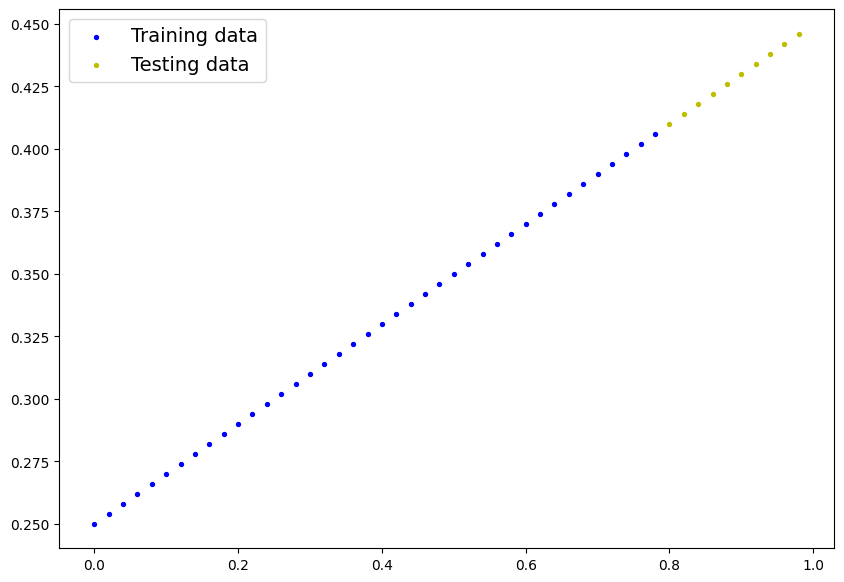

In [ ]:
plot_prediction()

# Builidng the PyTorch model
what the model does:
* Start with random values of weight and bias
* Look at the training data and adjust the random values to better represent (or get closer) to the ideal values(the weight and bias)

how is it done:
1. Gradient descent(fix those who caused the problem by updating new values)
2. Backpropagation(who caused problem)

In [ ]:
from torch import nn
# Create linear regression model class
class LinearRegressionModel(nn.Module):# <--nn.Module- Base class for newural networks modules, almost everything in pytorch inherits from nn.Module
    def __init__(self):
      super().__init__()
      self.weights=nn.Parameter(torch.rand(1,
                                           requires_grad=True,
                                           dtype=torch.float))
      self.bias=nn.Parameter(torch.rand(1,
                                        requires_grad=True,
                                        dtype=torch.float))
    # forward method to define computation in the model
    def forward(self, x: torch.tensor)->torch.Tensor:## "x"is the input data(training data)
           return self.weights*x+self.bias

# Essesntials
*  `torch.nn` - contains all of the building blocks for computational graphs (a neural network is a computational graph)

*  `torch.nn.Parameter` - what parameters should our model try and learn,often a Pytorch layer from `torch.nn` will set these for us

*  `torch.nn.Module`  -- The base class for all neural networks modules,if u subclass it u should override `forward()`

*  `torch.optim`  - this is where the optimizers in PyTorch live,they will help with the gradient descent by providing algorithms

* `def forward()` - all nn.Module subclases require you to overwrite forward(),this method defines what happens in the forward computation

In [ ]:
# we can check the parameters inside the using-.parameters()
torch.manual_seed(94)

# create an instance of the model(this is the subclass of nn.module)
model_0=LinearRegressionModel()

print(list(model_0.parameters()))
print(model_0.state_dict())
weight,bias

[Parameter containing:
tensor([0.1628], requires_grad=True), Parameter containing:
tensor([0.0004], requires_grad=True)]
OrderedDict({'weights': tensor([0.1628]), 'bias': tensor([0.0004])})


(0.2, 0.25)

now these two values of weights and bias which are 0.1628 and 0.0004 must be almost equal too he weight and bias we gave at the starting i.e 0.2 and 0.25

# Making prediction using `torch.inference_mode()`

to check our model's predictive power,lets see how well it predicts `y_test` based on `X_test`

When we paass data through a model its going to run it through a `forward()` method

**`torch.inference_mode()` works similar to  `torch.no_grad()`**


In [ ]:
# make predictions with model
%%time
with torch.inference_mode():
  y_preds=model_0(X_test)
y_preds

CPU times: user 0 ns, sys: 778 µs, total: 778 µs
Wall time: 1.05 ms


tensor([[0.1306],
        [0.1339],
        [0.1371],
        [0.1404],
        [0.1436],
        [0.1469],
        [0.1501],
        [0.1534],
        [0.1566],
        [0.1599]])

In [ ]:
#without torch.inference_mode()
%%time
y_preds_without=model_0(X_test)
y_preds_without

CPU times: user 0 ns, sys: 862 µs, total: 862 µs
Wall time: 2.3 ms


tensor([[0.1306],
        [0.1339],
        [0.1371],
        [0.1404],
        [0.1436],
        [0.1469],
        [0.1501],
        [0.1534],
        [0.1566],
        [0.1599]], grad_fn=<AddBackward0>)

Here we observe that even without using `torch.inference_mode()` we get almost the same prediction value but when we use `torch.inference_mode()`
we dont get extra info like( grad_func) ..what does torch.inference_mode() do:

* Turns off gradient tracking

* Turns off autograd graph construction

it saves memory, bookkeeping and overhead

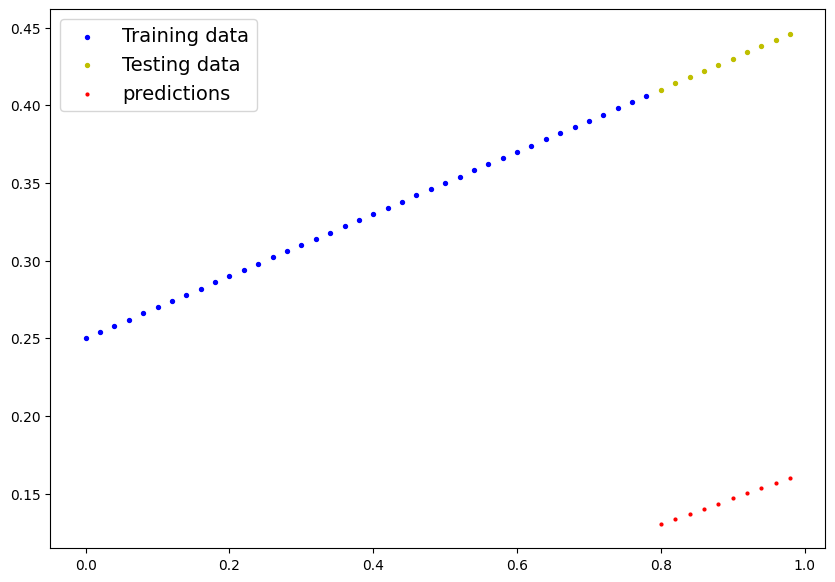

In [ ]:
plot_prediction(predictions=y_preds)

#`Loss function`

It is a function to measure how wrong your model's predictions are to the ideal ouputs,lower is better

#`Optimizer`
Takes  into account thee loss of a model and adjusts the model's parameters(e.h weight and bias) to improve the loss function.
 * Inside optimizer you'll foten learn about:
    * `params=` the model parameters you've gottaoptimize(e.g model_0.parameters()
    * `lr=`(learning rate): possibly the most imp hyperparameter you can set ,more like step size-the small the lr the small the change in param and sme w large lr

And specifically for pytorch we need a:
* A Training loop
* A Testing loop

#Setting up a Loss function
`torch.nn.L1Loss`-is the Mean Absolute Error

In [ ]:
#loss function
loss_fn=nn.L1Loss()

#set up an optimizer(stochastic gradient descent-trail and error type ,by adjusting the guess and comparing loss it lands on a number with safe loss range )
optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.01)#lr=lerning rate

Q: Which loss function and optimizer to be used?

* if regression use loss function `nn.L1Loss()` and optimizer `torch.optim.SGD()`
* if classification use loss function `nn.BCELoss()`

#Building a training loop( and a testing loop) in PyTorch

A couple of things we need in a traing loop:
1. Loop through the data_parallel
2. Forward propagation
3. Calculate the loss(compare forward pass predictions to ground truth labels)
4. Optimizer zero grad
5. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our models with respect to the loss(**backpropagation**)
6. Optimizer step - use the optimizzer step to improve the loss by adjusting the parameters of model(**gradient descent**) refer to thiiss:https://aicorr.com/wp-content/uploads/2024/03/What-is-Gradient-Descent-in-Machine-Learning_.jpg

In [ ]:
# An epoch is a one loop through the data...
epochs=100
#Tracking
epoch_count=[]
loss_values=[]
test_loss_values=[]
##training
#0. Loop through data
for epoch in range(epochs):
#Set the model to training mode
   model_0.train()# train mode in Pytorch sets all parameters that require gradients to require gradient

   #1.forward pass
   y_pred=model_0(X_train)

   #2.calculate the loss
   loss=loss_fn(y_pred,y_train)# loss_function(prediction first,result last)
   #3. optimizer zero grad-->for each iteration we get a gradient value at step 5 nd if we dont reset it, it gets accumulated
   optimizer.zero_grad()

   #4.loss backward(BACKPROPAGATRION)
   loss.backward()

   #5.optimizer step
   optimizer.step()

   ##Testing
   model_0.eval()# put model in evluation mode

   with torch.inference_mode():#turns off gradient tracking
    #1.forward pass
     test_pred=model_0(X_test)

    #2.calculate the loss
     test_loss=loss_fn(test_pred,y_test.type(torch.float))

     if epoch%10==0:
        epoch_count.append(epoch)
        loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"epoch: {epoch}  Loss:{loss}  Test loss: {test_loss}")

epoch: 0  Loss:0.26413673162460327  Test loss: 0.2692849934101105
epoch: 10  Loss:0.14892669022083282  Test loss: 0.13457496464252472
epoch: 20  Loss:0.03371663764119148  Test loss: 0.002233073115348816
epoch: 30  Loss:0.007766558788716793  Test loss: 0.01720203459262848
epoch: 40  Loss:0.004331700503826141  Test loss: 0.009616518393158913
epoch: 50  Loss:0.0025553300511091948  Test loss: 0.008134910836815834
epoch: 60  Loss:0.0025553300511091948  Test loss: 0.008134910836815834
epoch: 70  Loss:0.0025553300511091948  Test loss: 0.008134910836815834
epoch: 80  Loss:0.0025553300511091948  Test loss: 0.008134910836815834
epoch: 90  Loss:0.0025553300511091948  Test loss: 0.008134910836815834


In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.2056])), ('bias', tensor([0.2504]))])

It went from 0.168 and 0.0004 to 0.20 and 0.25

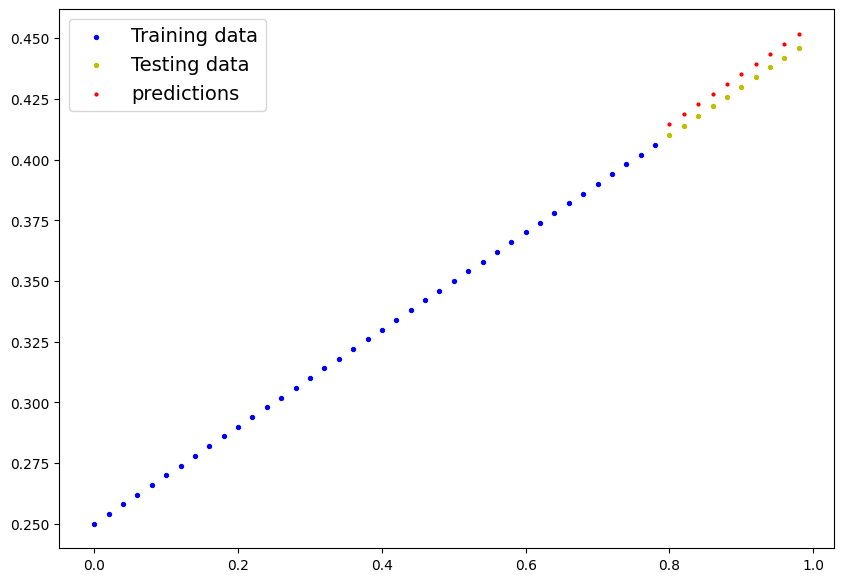

In [ ]:
#now we got the weight and bias changed and now we do the plot again using new weight and bias and predicted values
with torch.inference_mode():
  y_pred_new=model_0(X_test)
plot_prediction(predictions=y_pred_new)

In [ ]:
epoch_count,loss_values,test_loss_values

([0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
 [array(0.26413673, dtype=float32),
  array(0.14892669, dtype=float32),
  array(0.03371664, dtype=float32),
  array(0.00776656, dtype=float32),
  array(0.0043317, dtype=float32),
  array(0.00255533, dtype=float32),
  array(0.00255533, dtype=float32),
  array(0.00255533, dtype=float32),
  array(0.00255533, dtype=float32),
  array(0.00255533, dtype=float32)],
 [array(0.269285, dtype=float32),
  array(0.13457496, dtype=float32),
  array(0.00223307, dtype=float32),
  array(0.01720203, dtype=float32),
  array(0.00961652, dtype=float32),
  array(0.00813491, dtype=float32),
  array(0.00813491, dtype=float32),
  array(0.00813491, dtype=float32),
  array(0.00813491, dtype=float32),
  array(0.00813491, dtype=float32)])

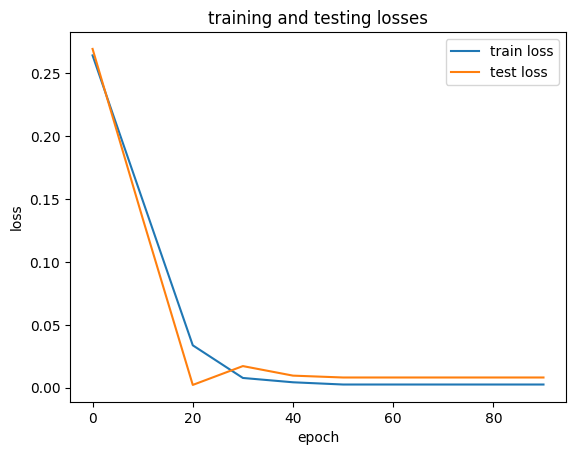

In [ ]:

plt.plot(epoch_count,loss_values,label="train loss")
plt.plot(epoch_count,test_loss_values,label="test loss")
plt.title("training and testing losses")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend();

#Saving a modeel in PyTorch

There are three main methods to save and load your model in PyTorch:

1. `torch.save(obj=model.state_dict,f=PATH)` - allows you to save PyTorch object in Python's pickle (serializing)format
2. `torch.load()` - allows you load a saved Pytorch object(it deserializes)
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary

In [ ]:
from pathlib import Path

#1. create model's directory
model_path = Path("models")
model_path.mkdir(parents=True,exist_ok=True)

#2. Create model save path
model_name="01_pytorch_workflow_model_0.pth"
model_save_path= model_path / model_name
model_save_path

#3. save the model state_dict
print("Saving model to..",model_save_path)
torch.save(model_0.state_dict(),model_save_path)

Saving model to.. models/01_pytorch_workflow_model_0.pth


#Loading a PyTorch model

Since we saved our mode's `save_dict()` rather than entire model, we'll create a new instance of our odel class and `save_dict()` into that

In [ ]:
#new instance
loaded_model_0=LinearRegressionModel()

# Load the saved state_dict of model_0(this will load new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(model_save_path))


<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.2056])), ('bias', tensor([0.2504]))])

In [ ]:
# Make some predicions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds=loaded_model_0(X_test)
y_pred_new==loaded_model_preds
#yayy!! they match w our loaded model

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# Putting all together (Revise)

In [ ]:
#Import PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

#Check pyTroch version
torch.__version__

'2.9.0+cu126'

Create device-agnostic code

that means if we have GPU available then let the operations be done in GPU device else let it be on CPU

`device="cuda" if torch.cuda.is_available() else "cpu"`

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"

# 1.1 Data

In [ ]:
#Creat some data using linear regression formula
weight1=0.5
bias1=0.3
start1=2
stop1=3
step1=0.02
X1=torch.arange(start1,stop1,step1).unsqueeze(dim=1)
y1=weight*X1+bias
X1.shape,y1.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [ ]:
#Split the data to 70% train data and 30% of test data
train_split=int(0.7*len(X1))
X1_train,y1_train=X1[:train_split],y1[:train_split]
X1_test,y1_test=X1[train_split:],y1[train_split:]
len(X1_train),len(y1_train),len(X1_test),len(y1_test)

(35, 35, 15, 15)

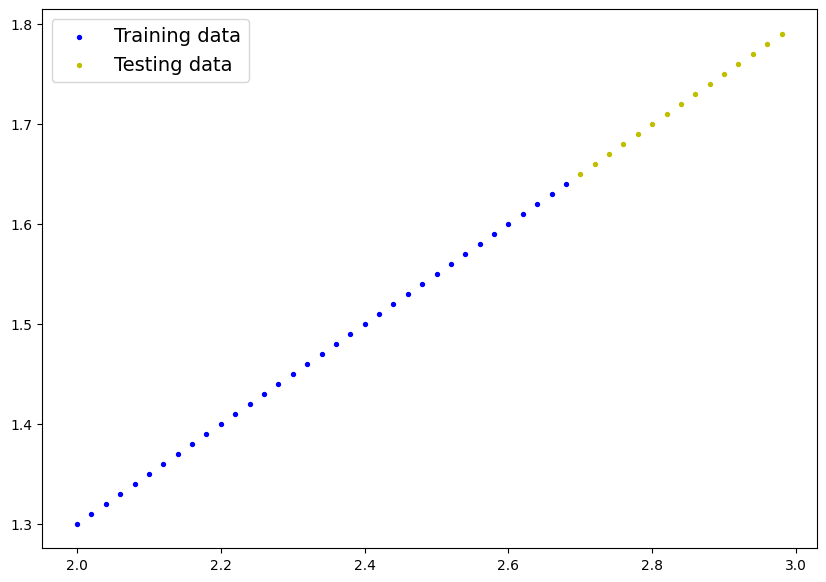

In [ ]:
#plotting
plot_prediction(X1_train,y1_train,X1_test,y1_test)

# 1.2 Building a PyTorch Linear Model


`nn.Linear(in_features,out_features)` basically does the ax+c thing implicitly internally, like it takes params ny itself and applies the formula to the incoming data

In [ ]:
class LinearRegressionModel1(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer=nn.Linear(in_features=1,
                                out_features=1)
  def forward(self,x:torch.Tensor)->torch.Tensor:
     return self.linear_layer(x)# it is called and it does its operation

In [ ]:
torch.manual_seed(201)
model_1=LinearRegressionModel1()
model_1

LinearRegressionModel1(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(model_1.parameters()).device


device(type='cpu')

In [ ]:
# set model to use the target device
model_1.to(device)
next(model_1.parameters()).device


device(type='cuda', index=0)

# 1.3 Predicting

In [ ]:
with torch.inference_mode():
    y1_preds=model_1(X1_test)


RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

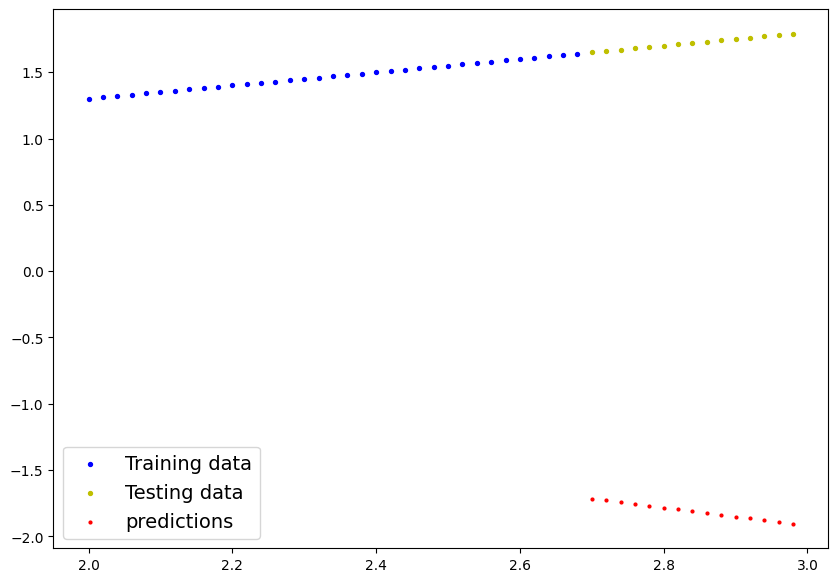

In [ ]:
plot_prediction(X1_train.cpu(),y1_train.cpu(),X1_test.cpu(),y1_test.cpu(),y1_preds.cpu())

# 1.4 Set up a Loss function

In [ ]:
# Loss function
model_1.state_dict()
loss1_fn=nn.L1Loss()

# Optimizer
optimizer1=torch.optim.SGD(params=model_1.parameters(),
                           lr=0.01) # Reduced learning rate to 0.01

# 1.5 Training

In [ ]:
epochs=100

epoch1_count=[]
train1_loss_values=[]
test1_loss_values=[]

# Move data and model to target device
X1_train = X1_train.to(device)
y1_train = y1_train.to(device)
X1_test = X1_test.to(device)
y1_test = y1_test.to(device)


for epoch in range(epochs):
  model_1.train()

  #1.forward pass
  y1_pred=model_1(X1_train)

  #2. calculate the loss
  loss1=loss1_fn(y1_pred,y1_train)

  #3. optimizer zero grad
  optimizer1.zero_grad()

  #4. backpropagation
  loss1.backward()

  #5. gradient descent
  optimizer1.step()

  ##Testing
  model_1.eval()

  with torch.inference_mode():
    test1_pred=model_1(X1_test)
    test1_loss=loss1_fn(test1_pred,y1_test)

  if epoch%10==0:
    epoch1_count.append(epoch)
    train1_loss_values.append(loss1.detach().cpu().numpy()) # Corrected variable name
    test1_loss_values.append(test1_loss.detach().cpu().numpy()) # Corrected variable name
    print(f"epoch: {epoch}  Loss:{loss1}  Test loss: {test1_loss}")

epoch: 0  Loss:0.018204886466264725  Test loss: 0.05215774476528168
epoch: 10  Loss:0.01773875020444393  Test loss: 0.050913255661726
epoch: 20  Loss:0.017272623255848885  Test loss: 0.04966875910758972
epoch: 30  Loss:0.016806475818157196  Test loss: 0.04842427000403404
epoch: 40  Loss:0.016340354457497597  Test loss: 0.047179773449897766
epoch: 50  Loss:0.015874218195676804  Test loss: 0.04593528434634209
epoch: 60  Loss:0.016792478039860725  Test loss: 0.054824475198984146
epoch: 70  Loss:0.028580961748957634  Test loss: 0.08592721819877625
epoch: 80  Loss:0.028580961748957634  Test loss: 0.08592721819877625
epoch: 90  Loss:0.028580961748957634  Test loss: 0.08592721819877625


In [ ]:
with torch.inference_mode():
  y1_pred_new=model_1(X1_test)
y1_pred_new

tensor([[1.6512],
        [1.6597],
        [1.6681],
        [1.6766],
        [1.6851],
        [1.6936],
        [1.7021],
        [1.7105],
        [1.7190],
        [1.7275],
        [1.7360],
        [1.7444],
        [1.7529],
        [1.7614],
        [1.7699]], device='cuda:0')

In [ ]:
list(model_1.parameters())

[Parameter containing:
 tensor([[0.4239]], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.5067], device='cuda:0', requires_grad=True)]

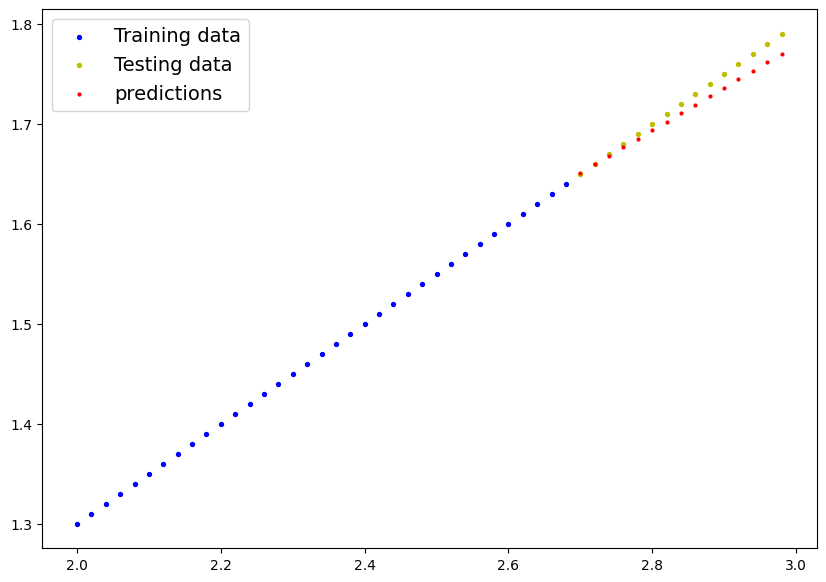

In [ ]:
plot_prediction(X1_train.cpu(),y1_train.cpu(),X1_test.cpu(),y1_test.cpu(),y1_pred_new.cpu())